In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt
from scipy.stats import pearsonr,wilcoxon,mannwhitneyu,kruskal
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore
import scipy.io as spio

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [27]:
### Function to convert matlab struct to python dictionary, adapted from https://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries
def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, spio.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [28]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [29]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [ ]:
### Get Chr2 data for Fig5D, 5F (Left), 5G (Left)
id_date = { 
"004106" : ["20230908"],
"004155" : ["20230908"],
"004107" : ["20230908"],
"004105" : ["20230728"],
"004103" : ["20230728"],
"004104" : ["20230728"]
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        data = mat_data["response"]["sessdata"]
        laser_times = mat_data["response"]["laser_time"]
        laser_itis = mat_data["response"]["trial_iti"]
        laser_widths = mat_data["response"]["trial_pulse_width"]
        laser_freqs = [np.round((width/(iti + width)) * 100) for iti,width in zip(laser_itis,laser_widths)]
        trans = np.transpose(data)
        ard_times = trans[4]
        wheel = trans[3]
        wheel[0] = 0
        wheel = zscore(np.interp(times,ard_times,wheel))
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(wheel_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "wheel", "ID" : id, "date" : date,"sess":sess,"frequency":str(int(laser_freqs[j]))}
                df_list.append(new_dict)

        for j,trial in enumerate(pupil_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "pupil", "ID" : id, "date" : date,"sess":sess,"frequency":str(int(laser_freqs[j]))}
                df_list.append(new_dict)

        for j,trial in enumerate(face_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(face_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "face", "ID" : id, "date" : date,"sess":sess,"frequency":str(int(laser_freqs[j]))}
                df_list.append(new_dict)

opto_df = pd.DataFrame.from_dict(df_list)

004106 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004155 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/2708903325.py:57: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(trial

004107 20230908


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004103 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004104 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


In [15]:
### Get mCherry data for Fig5D

id_date = { 
"004259" : ["20240513"],
"004260" : ["20240513"],
"004261" : ["20240513"],
"004263": ["20240513"],
"004262" : ["20240513"],
"004264" : ["20240513"],
}
sess =1
pre = 10
post = 20
df_list = []
labels = list(range(1,5))
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]

        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i], "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)

mcherry_df = pd.DataFrame.from_dict(df_list)

004259 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004260 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004261 20240513


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004262 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004264 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/1334932474.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = opto_df.query("frequency == '20'").query("type == 'pupil'").groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/1334932474.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = mcherry_df.groupby(["ID","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)

Text(0, 0.5, 'Pupil Size (z-scr)')

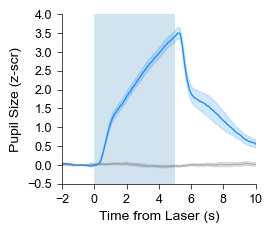

In [16]:
### Plot Fig5D

plt.figure(figsize = (2.5,2.2))
ax = sns.lineplot(data = opto_df.query("frequency == '20'").query("type == 'pupil'").groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1)
sns.lineplot(data = mcherry_df.groupby(["ID","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "grey",linewidth = 1,alpha = 0.5)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,10],[-0.5,4],2,0.5)
ax.set_xlabel("Time from Laser (s)")
ax.set_ylabel("Pupil Size (z-scr)")

In [19]:
### Get data for Fig5E (Top), 5F (Right), 5G (right)
id_date = { 
"004106" : ["20230908"],
"004155" : ["20230908"],
"004107" : ["20230908"],
"004105" : ["20230728"],
"004103" : ["20230728"],
"004104" : ["20230728"]
}

sess =1
pre = 10
post = 10
df_list = []
delta_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        data = mat_data["response"]["sessdata"]
        laser_times = mat_data["response"]["laser_time"]
        laser_itis = mat_data["response"]["trial_iti"]
        laser_widths = mat_data["response"]["trial_pulse_width"]
        laser_freqs = [np.round((width/(iti + width)) * 100) for iti,width in zip(laser_itis,laser_widths)]
        trans = np.transpose(data)
        ard_times = trans[4]
        wheel = trans[3]
        wheel[0] = 0
        wheel = zscore(np.interp(times,ard_times,wheel))
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            delta = post_laser - pre_laser
            delta_dict = {"Delta" : delta,"ID" : id,'type':"wheel","Date":date,"trial":j,"frequency":str(int(laser_freqs[j]))}
            delta_list.append(delta_dict)

    

        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            delta = post_laser - pre_laser
            delta_dict = {"Delta" : delta,"ID" : id,'type':"pupil","Date":date,"trial":j,"frequency":str(int(laser_freqs[j]))}
            delta_list.append(delta_dict)


        for j,trial in enumerate(face_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[200:220])
            delta = post_laser - pre_laser
            delta_dict = {"Delta" : delta,"ID" : id,'type':"face","Date":date,"trial":j,"frequency":str(int(laser_freqs[j]))}
            delta_list.append(delta_dict)

delta_df = pd.DataFrame.from_dict(delta_list)

004106 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004155 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/2800758776.py:61: RuntimeWarning: Mean of empty slice
  pre_laser = np.nanmean(tria

004107 20230908


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004103 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004104 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


In [20]:
### Get data for Fig5E (Bottom)

id_date = { 
"004259": ["20240513"],
"004260": ["20240513"],
"004261": ["20240513"],
"004262": ["20240513"],
"004263": ["20240513"],
"004264": ["20240513"],

}
sess =1
pre = 10
post = 10
df_list = []
delta_list = []

for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]

        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            new_dict = {"Delta" : post_laser - pre_laser,"ID" : id,'Condition':"mCherry","Date":date,"trial":j}
            delta_list.append(new_dict)

mcherry_delta_df = pd.DataFrame.from_dict(delta_list)

004259 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004260 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004261 20240513


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004263 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004264 20240513


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/3909989673.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = delta_df.query("frequency == '20'").query("type == 'pupil'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/3909989673.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = delta_df.query("frequency == '20'").query("type == 'pupil'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3

Text(0.5, 0, 'ChR2')

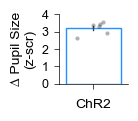

In [22]:
### Plot Fig5E (Top)
plt.figure(figsize = (0.9,0.9))
g = sns.barplot(data = delta_df.query("frequency == '20'").query("type == 'pupil'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.stripplot(data = delta_df.query("frequency == '20'").query("type == 'pupil'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.25)
g.set_yticks(np.arange(0,5,1))
g.set(ylim=(0, 4))
g.set_ylabel("∆ Pupil Size\n(z-scr)")
g.set_xlabel("ChR2")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/665181483.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/665181483.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.25)


Text(0.5, 0, 'mCherry')

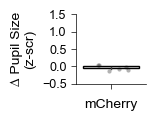

In [21]:
### Plot Fig5E (Bottom)

plt.figure(figsize = (0.9,0.9))
g = sns.barplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black")
sns.stripplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.25)

g.set_yticks(np.arange(-0.5,2,0.5))
g.set(ylim=(-0.5, 1.5))
g.set_ylabel("∆ Pupil Size\n(z-scr)")
g.set_xlabel("mCherry")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/1360545716.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = opto_df.query("frequency == '20'").query("type == 'wheel'").groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "darkorange",linewidth = 1)


Text(0, 0.5, 'Running Speed\n(z-scr)')

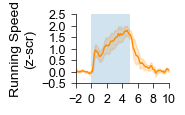

In [ ]:
### Plot Fig5F (Left)
plt.figure(figsize = (1.2,0.9))

ax = sns.lineplot(data = opto_df.query("frequency == '20'").query("type == 'wheel'").groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "darkorange",linewidth = 1)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,10],[-0.5,2.5],2,0.5)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("Running Speed\n(z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/2573456264.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = delta_df.query("frequency == '20'").query("type == 'wheel'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/2573456264.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = delta_df.query("frequency == '20'").query("type == 'wheel'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3

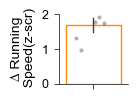

In [ ]:
### Plot Fig5F (Right)

plt.figure(figsize = (0.9,0.9))
g = sns.barplot(data = delta_df.query("frequency == '20'").query("type == 'wheel'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
sns.stripplot(data = delta_df.query("frequency == '20'").query("type == 'wheel'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.25)
g.set_yticks(np.arange(0,3,1))
g.set(ylim=(0, 2))
g.set_ylabel("∆ Running\n Speed(z-scr)")
g.xaxis.label.set_visible(False)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/3427053942.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = opto_df.query("frequency == '20'").query("type == 'face'").groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "purple",linewidth = 1)


Text(0, 0.5, 'Facial Movement\n(z-scr)')

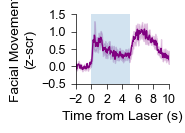

In [ ]:
### Plot Fig5G (Left)
plt.figure(figsize = (1.2,0.9))
ax = sns.lineplot(data = opto_df.query("frequency == '20'").query("type == 'face'").groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "purple",linewidth = 1)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,10],[-0.5,1.5],2,0.5)
ax.set_xlabel("Time from Laser (s)")
ax.set_ylabel("Facial Movement\n(z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/1711508327.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = delta_df.query("frequency == '20'").query("type == 'face'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_24622/1711508327.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = delta_df.query("frequency == '20'").query("type == 'face'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3

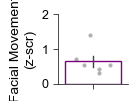

In [ ]:
### Plot Fig5G (Right)

plt.figure(figsize = (0.9,0.9))
g = sns.barplot(data = delta_df.query("frequency == '20'").query("type == 'face'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
sns.stripplot(data = delta_df.query("frequency == '20'").query("type == 'face'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.25)
g.set_yticks(np.arange(0,3,1))
g.set(ylim=(0, 2))
g.set_ylabel("Facial Movement\n(z-scr)")
g.xaxis.label.set_visible(False)

